CNN

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import warnings
warnings.filterwarnings("ignore")

In [3]:
os.chdir(r"dataset")

In [4]:
os.getcwd()

'C:\\Users\\lenovo\\dataset'

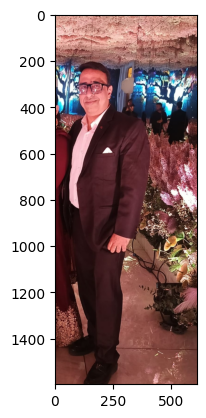

In [5]:
img = image.load_img("training/Papa/p1.jpeg")
plt.imshow(img)

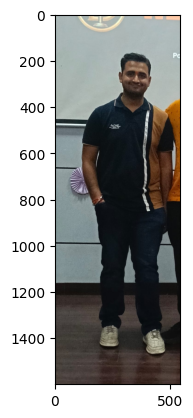

In [6]:
img = image.load_img("testing/t1.jpeg")
plt.imshow(img)

In [7]:
train = ImageDataGenerator(rescale= 1/255)
validation = ImageDataGenerator(rescale= 1/255)

In [10]:
tr_location = r"C:\Users\lenovo\dataset\training"
val_location = r"C:\Users\lenovo\dataset\validation"

In [11]:
train_data = train.flow_from_directory(tr_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "categorical")
valid_data = validation.flow_from_directory(val_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "categorical")

Found 40 images belonging to 4 classes.
Found 16 images belonging to 4 classes.


In [12]:
train_data.class_indices

{'Khush': 0, 'Mummy': 1, 'Papa': 2, 'Unknown': 3}

In [13]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(16,(3,3),activation="relu",input_shape=(200,200,3)),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3), activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512,activation="relu"),

    tf.keras.layers.Dense(4, activation="softmax")
])

In [14]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 198, 198, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 99, 99, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 97, 97, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 46, 46, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 33856)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      17,334,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,360,420 (66.22 MB)

 Trainable params: 17,360,420 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(loss="categorical_crossentropy",optimizer=RMSprop(learning_rate=0.001),metrics=["accuracy"])

In [16]:
model.fit(train_data,
          steps_per_epoch=8,
          epochs=10,
          validation_data=valid_data)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 314ms/step - accuracy: 0.1250 - loss: 2.3117 - val_accuracy: 0.3750 - val_loss: 1.3733
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.1875 - loss: 1.3978 - val_accuracy: 0.5625 - val_loss: 1.3129
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - accuracy: 0.2727 - loss: 1.3840 - val_accuracy: 0.4375 - val_loss: 1.2301
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.3889 - loss: 1.3056 - val_accuracy: 0.3125 - val_loss: 1.1984
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - accuracy: 0.4583 - loss: 1.2758 - val_accuracy: 0.8750 - val_loss: 0.8770
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.5625 - loss: 1.3543 - val_accuracy: 0.9375 - val_loss: 0.9013
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - accuracy: 0.5000 - loss: 1.1063 - val_accuracy: 0.8125 - val_loss: 0.8128
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.6667 - loss: 0.8731 - val_accuracy: 0.8750 - val_loss:

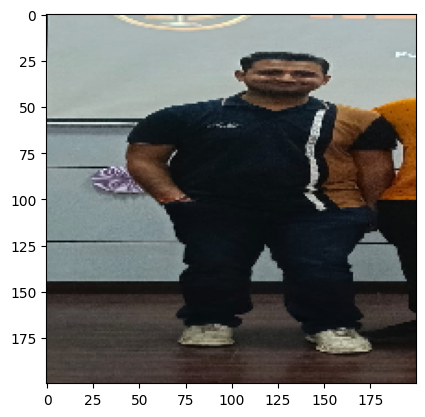

Detected Person : Khush
Confidence : 100.00%
✅ Welcome Khush
----------------------------------------


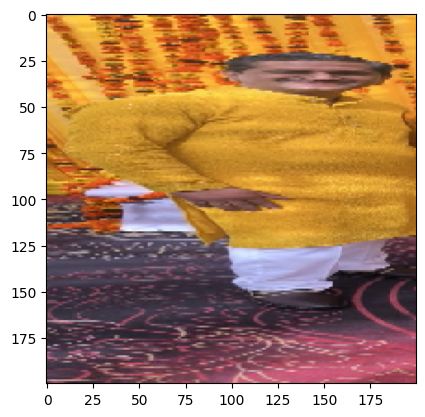

Detected Person : Unknown
Confidence : 100.00%
❌ Access Denied
----------------------------------------


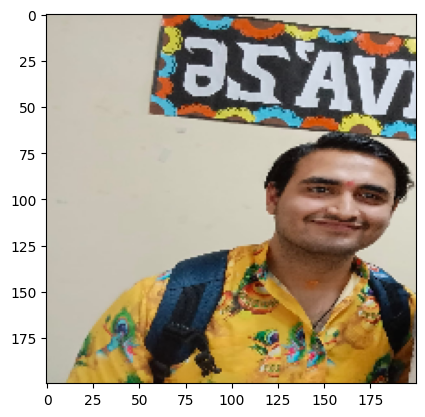

Detected Person : Khush
Confidence : 100.00%
✅ Welcome Khush
----------------------------------------


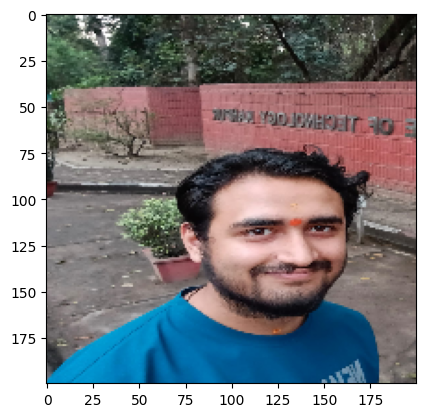

Detected Person : Khush
Confidence : 100.00%
✅ Welcome Khush
----------------------------------------


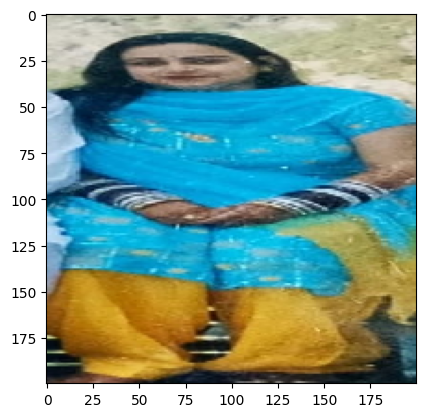

Detected Person : Mummy
Confidence : 100.00%
✅ Welcome Mummy
----------------------------------------


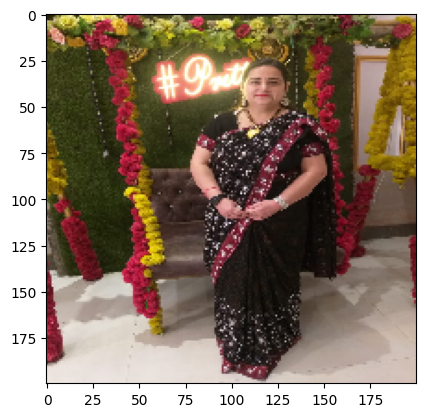

Detected Person : Mummy
Confidence : 100.00%
✅ Welcome Mummy
----------------------------------------


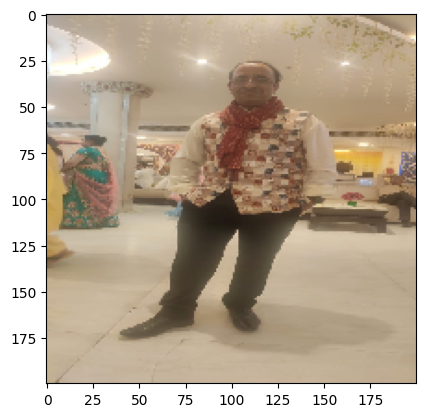

Detected Person : Papa
Confidence : 100.00%
✅ Welcome Papa
----------------------------------------


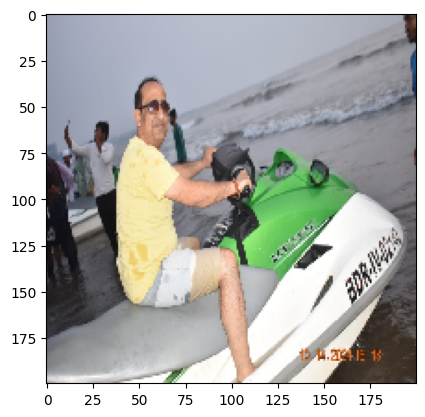

Detected Person : Papa
Confidence : 100.00%
✅ Welcome Papa
----------------------------------------


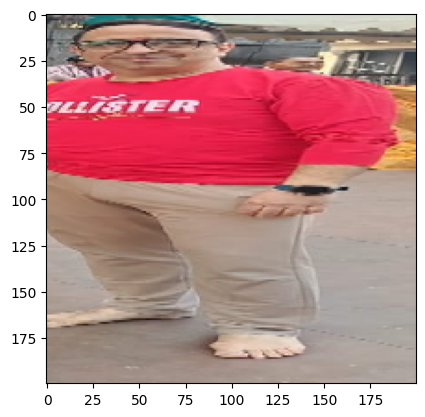

Detected Person : Papa
Confidence : 100.00%
✅ Welcome Papa
----------------------------------------


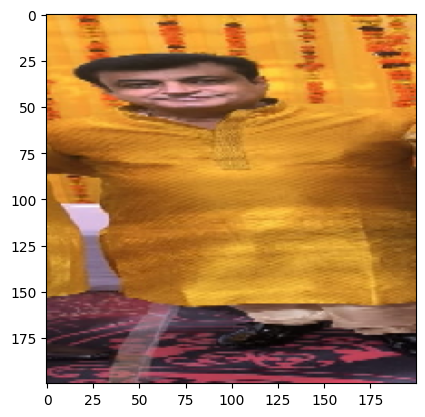

Detected Person : Unknown
Confidence : 100.00%
❌ Access Denied
----------------------------------------


In [17]:
path = r"C:\Users\lenovo\dataset\Testing"

class_names = ['Khush', 'Mummy', 'Papa', 'Unknown']

for i in os.listdir(path):

    img = image.load_img(path + "/" + i, target_size=(200,200))
    plt.imshow(img)
    plt.show()

    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    prediction = model.predict(x, verbose=0)

    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    print("Detected Person :", class_names[predicted_class])
    print(f"Confidence : {confidence:.2f}%")

    if class_names[predicted_class] == "Unknown":
        print("❌ Access Denied")
    else:
        print(f"✅ Welcome {class_names[predicted_class]}")

    print("-"*40)

In [18]:
model.save("visionlock_model.keras")